In [1]:
import numpy as np
import pandas as pd
import warnings
import os
import matplotlib.pyplot as plt
import seaborn as sns

#### helping functions/ methods

In [2]:
def get_dataset(dataset:str)->str:
    try:
        return pd.read_csv(os.path.join('..','data','raw',f'{dataset}.csv'))
    except Exception as e:
        warnings.warn(f'"{dataset}" dataset not present.')
        return None

In [3]:
def check_is_unique(dataframe,column_names):
    '''
    print that the given columns is unique or not.
    parameters:
    dataframe: pandas dataframe
    column_name : name of the column which want to check.
    '''
    if  type(column_names) == str:
        print(f"'{column_names}' is a unique in table ? { dataframe[column_names].is_unique}")
        return; 
    else:
        for column_name in column_names:
            print(f"'{column_name}' is a unique in table ? { dataframe[column_name].is_unique}")


### Load the datasets

In [4]:
# import the dataset
df_customers = get_dataset('customers')
df_order_items  = get_dataset('order_items')
df_geolocation = get_dataset('geolocation')
df_sellers = get_dataset('sellers')
df_orders = get_dataset('orders')
df_reviews = get_dataset('order_reviews')

#### understand the data

In [5]:
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


In [6]:
df_customers.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
df_customers.duplicated(subset=['customer_id'], keep=False).sum()

np.int64(0)

In [8]:
df_customers['customer_id'].is_unique

True

In [9]:
df_customers.duplicated(subset=['customer_unique_id'], keep=False).sum()

np.int64(6342)

In [10]:
df_customers[df_customers.duplicated(subset=['customer_unique_id'], keep=False)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
6,000419c5494106c306a97b5635748086,14843983d4a159080f6afe4b7f346e7c,24220,niteroi,RJ
8,00050bf6e01e69d5c0fd612f1bcfb69c,e3cf594a99e810f58af53ed4820f25e5,98700,ijui,RS
19,0010068a73b7c56da5758c3f9e5c7375,03dabd77cb0ed7a26fafe19e36b67742,63680,parambu,CE
29,00146ad30454993879adaa91c518f68c,5616f75d22507069b5383854a1d8c414,31060,belo horizonte,MG
60,002b5342c72978cf0aba6aae1f5d5293,76e5f3bca2b1f5c510c41563c2ea31a4,22775,rio de janeiro,RJ
...,...,...,...,...,...
99359,ffc436ef9df6ede268ee1548a0dfbbba,89e3027de49c3012858cfeb7f5a34f59,24724,sao goncalo,RJ
99423,fff4fdd0de70a51d4e0f57a4c1c6bfae,7b6d07dac0a2c373d749142e920ae356,9111,santo andre,SP
99428,fff7466a253c0e59499ea943462c10f9,1b6c7548a2a1f9037c1fd3ddfed95f33,38301,ituiutaba,MG
99431,fff93c1da78dafaaa304ff032abc6205,d8dc373219d0f95053c8d65df85a7f1c,14802,araraquara,SP


### table2. order 

In [11]:
df_orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05


In [12]:
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [13]:
check_is_unique(df_orders,'order_id')
check_is_unique(df_orders,'customer_id')


'order_id' is a unique in table ? True
'customer_id' is a unique in table ? True


In [14]:
df_orders.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [15]:
df_orders = df_orders.dropna(axis=0)

In [16]:
df_orders.info()

<class 'pandas.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       96461 non-null  str  
 1   customer_id                    96461 non-null  str  
 2   order_status                   96461 non-null  str  
 3   order_purchase_timestamp       96461 non-null  str  
 4   order_approved_at              96461 non-null  str  
 5   order_delivered_carrier_date   96461 non-null  str  
 6   order_delivered_customer_date  96461 non-null  str  
 7   order_estimated_delivery_date  96461 non-null  str  
dtypes: str(8)
memory usage: 6.6 MB


In [17]:
df_orders = df_orders[df_orders['order_status']=='delivered']

In [18]:
#check duplicate records.
df_orders.duplicated().sum()

np.int64(0)

### table 3. order_items 

In [19]:
df_order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [20]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [21]:
check_is_unique(df_order_items,'order_item_id')
check_is_unique(df_order_items,'order_id')
check_is_unique(df_order_items,'seller_id')
check_is_unique(df_order_items,'product_id')


'order_item_id' is a unique in table ? False
'order_id' is a unique in table ? False
'seller_id' is a unique in table ? False
'product_id' is a unique in table ? False


In [22]:
df_order_items.duplicated().sum()

np.int64(0)

In [23]:
df_order_items.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [24]:
df_order_items.duplicated(subset=['order_item_id'],keep='first').sum()

np.int64(112629)

In [25]:
df_order_items.duplicated(subset=['order_id','order_item_id']).sum()

np.int64(0)

In [26]:
df_order_items['order_item_id'].nunique()

21

In [27]:
df_order_items.groupby('order_id')['order_item_id'].count().sort_values(ascending=False)

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
9ef13efd6949e4573a18964dd1bbe7f5    15
428a2f660dc84138d969ccd69a0ab6d5    15
                                    ..
fff1e3e76b816bfe8ef16678cc53c643     1
fff2cdc825f9fc0ba3c04227cfa02303     1
fff2e9e3aa8644e19710216b4ef53ab2     1
fff3983dfa3c5a0d752d8d17baa406a0     1
fffe41c64501cc87c801fd61db3f6244     1
Name: order_item_id, Length: 98666, dtype: int64

In [28]:
df_order_items['product_id'].value_counts().count()

np.int64(32951)

### table.4 geolocation

In [29]:
df_geolocation.head(3)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.551427,-46.634074,sao paulo,SP
1,1001,-23.551337,-46.634027,sao paulo,SP
2,1001,-23.550642,-46.634410,sao paulo,SP


In [30]:
df_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 720154 entries, 0 to 720153
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  720154 non-null  int64  
 1   geolocation_lat              720154 non-null  float64
 2   geolocation_lng              720154 non-null  float64
 3   geolocation_city             720154 non-null  str    
 4   geolocation_state            720154 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 27.5 MB


In [31]:
check_is_unique(df_geolocation,'geolocation_zip_code_prefix')

'geolocation_zip_code_prefix' is a unique in table ? False


In [32]:
df_geolocation.duplicated(subset=['geolocation_zip_code_prefix'],keep='first').sum()

np.int64(701139)

#### So there is catch that 'geolocation_zip_code_prefix' have the duplicate entries so in order to join it with customer and seller we first take average of latitude and longitude of each zip code

In [33]:
df_unique_geolocation = df_geolocation.groupby('geolocation_zip_code_prefix').agg({'geolocation_lat':'mean','geolocation_lng':'mean'}).reset_index()

In [34]:
check_is_unique(df_unique_geolocation,'geolocation_zip_code_prefix')

'geolocation_zip_code_prefix' is a unique in table ? True


In [35]:
df_unique_geolocation.info()

<class 'pandas.DataFrame'>
RangeIndex: 19015 entries, 0 to 19014
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19015 non-null  int64  
 1   geolocation_lat              19015 non-null  float64
 2   geolocation_lng              19015 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 445.8 KB


In [36]:
df_unique_geolocation[df_unique_geolocation['geolocation_lng']>100]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
18309,95130,14.585073,121.105394


In [37]:
df_geolocation[df_geolocation['geolocation_zip_code_prefix']==95130]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
692272,95130,14.585073,121.105394,santa lucia do piai,RS


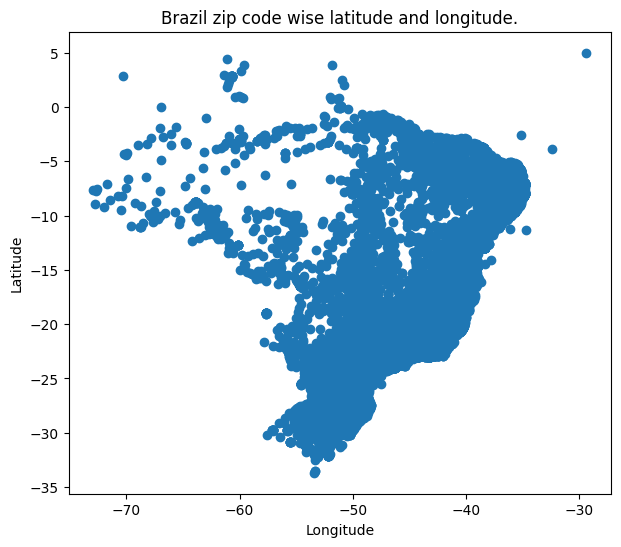

In [38]:
# Removing outliers

# only take zip code with comes under the brazil endpoint langitude and latitude.
#longitude
data =df_unique_geolocation[(df_unique_geolocation['geolocation_lng']>34.79277) & (df_unique_geolocation['geolocation_lng']<73.98444 )]
# Latitude
data = df_unique_geolocation[(df_unique_geolocation['geolocation_lat'] > -33.742222) & (df_unique_geolocation['geolocation_lat']<5.2722) ]

# remap to original data frame.
df_unique_geolocation =  data
plt.figure(figsize=(7,6))
plt.scatter(y = data['geolocation_lat'],x=data['geolocation_lng'])
plt.title('Brazil zip code wise latitude and longitude.')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show();

In [39]:
df_unique_geolocation.info()

<class 'pandas.DataFrame'>
Index: 19006 entries, 0 to 19014
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   geolocation_zip_code_prefix  19006 non-null  int64  
 1   geolocation_lat              19006 non-null  float64
 2   geolocation_lng              19006 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 593.9 KB


### table 5. Seller

In [40]:
df_sellers.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,0015a82c2db000af6aaaf3ae2ecb0532,9080,santo andre,SP
1,001cca7ae9ae17fb1caed9dfb1094831,29156,cariacica,ES
2,001e6ad469a905060d959994f1b41e4f,24754,sao goncalo,RJ


In [41]:
# check information 
df_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


In [42]:
check_is_unique(df_sellers,['seller_id','seller_zip_code_prefix','seller_city','seller_state'])

'seller_id' is a unique in table ? True
'seller_zip_code_prefix' is a unique in table ? False
'seller_city' is a unique in table ? False
'seller_state' is a unique in table ? False


In [43]:
# check duplicates

df_sellers.duplicated().sum()

np.int64(0)

### Merging all dataframe

In [72]:
# join the customer and orders dataframe 
df_master = pd.merge(left =df_customers,right=df_orders,on='customer_id',how='inner')
df_master.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP,5f79b5b0931d63f1a42989eb65b9da6e,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG,a44895d095d7e0702b6a162fa2dbeced,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES,316a104623542e4d75189bb372bc5f8d,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22


In [73]:
check_is_unique(df_master,['customer_id','customer_unique_id'])
print(f'lenght of dataset {len(df_master)}')

'customer_id' is a unique in table ? True
'customer_unique_id' is a unique in table ? False
lenght of dataset 96455


In [74]:
# now add the lattitude and longitude of each record of customer from geolocation ( 'unique_geolocation' ) dataframe.
df_master  = pd.merge(left=df_master, right = df_unique_geolocation, left_on = 'customer_zip_code_prefix',
         right_on = 'geolocation_zip_code_prefix', how = 'left')
# Important Column only
imp_col = ['customer_id','customer_unique_id','order_id','order_purchase_timestamp','order_approved_at',
 'order_delivered_carrier_date','order_delivered_customer_date','geolocation_lat','geolocation_lng']

df_master = df_master[imp_col]
df_master.rename(columns={'geolocation_lat':'customer_geolocation_lat','geolocation_lng':'customer_geolocation_lng'},inplace=True)
df_master.head(3)

,customer_id,customer_unique_id,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,customer_geolocation_lat,customer_geolocation_lng
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,5f79b5b0931d63f1a42989eb65b9da6e,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,-23.499149,-46.767812
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,a44895d095d7e0702b6a162fa2dbeced,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,-20.469287,-45.123459
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,316a104623542e4d75189bb372bc5f8d,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,-18.705783,-40.404736


In [80]:
# merge seller table with geolocation
 
df_seller_join_geolocation = pd.merge(left=df_sellers,right = df_unique_geolocation,
         left_on='seller_zip_code_prefix',right_on = 'geolocation_zip_code_prefix',how='left')
df_seller_join_geolocation.rename(columns={'geolocation_lat':'seller_geolocation_lat',
                                           'geolocation_lng':'seller_geolocation_lng'},inplace=True)
df_seller_join_geolocation.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,seller_geolocation_lat,seller_geolocation_lng
0,0015a82c2db000af6aaaf3ae2ecb0532,9080,santo andre,SP,9080.0,-23.640101,-46.542293
1,001cca7ae9ae17fb1caed9dfb1094831,29156,cariacica,ES,29156.0,-20.279224,-40.411514
2,001e6ad469a905060d959994f1b41e4f,24754,sao goncalo,RJ,24754.0,-22.872054,-43.027422


In [46]:
# now merge the order_items dataframe 

In [82]:
df_order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [48]:
check_is_unique(df_order_items,['order_id','seller_id'])

'order_id' is a unique in table ? False
'seller_id' is a unique in table ? False


In [49]:
# in order items dataframe their are product id store and order_id .
# one order_id is equal to 1 user order
# in 1 order their may have multiple products.and for those product are in this table.
# so first check total how many orders are placed.

order_count = pd.DataFrame( df_order_items.groupby('order_id')['product_id'].count().sort_values(ascending=False))
print(f'their are total "{len(order_count)}" orders are placed')
print(f'and total product sells are "{len(df_order_items)}" ')

their are total "98666" orders are placed
and total product sells are "112650" 


In [50]:

# ok so problem is if user order more than 1 items each items have different sellers. they live in differnet location.
# then how we may not track and calculate distance?

# my approch for this problem is, first it is not possible to have one distance for each order so now instead of taking 
# any single aggrigation like min,max.
# we are going to used multiple features as follow Min Distance, Max Distance, Avg Distance and No. of sellers.

In [81]:
# merge order_items with seller_geo table

# df_orderItem_join_sellerGeo
pd.merge(left=df_order_items,right=df_seller_join_geolocation,on='seller_id',how='left')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,seller_geolocation_lat,seller_geolocation_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP,27277.0,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP,3471.0,-23.565828,-46.519217
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG,37564.0,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP,14403.0,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR,87900.0,-22.929583,-53.135750
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,88303,itajai,SC,88303.0,-26.912525,-48.673996
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,1206,sao paulo,SP,1206.0,-23.535609,-46.643031
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,80610,curitiba,PR,80610.0,-25.469563,-49.288176
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,4733,sao paulo,SP,4733.0,-23.638757,-46.696289
